# 🙋 Lesson 10 · Human-in-the-Loop（HITL）

> **人在回路**：`interrupt` 暂停等人工审批，再用 `Command(resume=...)` 恢复。

本课你会学到：
- HITL 必须配合 Checkpoint（否则中断后无法恢复）
- `interrupt(...)` 如何把控制权交给人
- `Command(resume=...)` 如何把审批结果灌回图

模型：**DeepSeek V4 Pro**（`deepseek-v4-pro`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> C[chat_node]
    C --> I{interrupt<br/>审批?}
    I -->|denied| E([END / 拒绝])
    I -->|approved| LLM[deepseek-v4-pro 作答]
    LLM --> E2([END])

    CP[(Checkpointer<br/>thread_id)] -.-> C
    CP -.-> LLM


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class C tool
    class I branch
    class LLM llm
    class CP tool
    class E,E2 output
```


**要点：** HITL = 中断 + 人工输入 + 恢复；依赖持久化线程状态。



# Imports

`interrupt` / `Command` 来自 `langgraph.types`；必须配合 Checkpointer。


In [1]:
from typing import Annotated, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage, BaseMessage
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


In [2]:
load_dotenv()

True

In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

llm = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,
    max_tokens=1200,
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)

# 定义 State（消息列表）


In [4]:
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

# Node — chat_node

内部调用 `interrupt` 等待人工批准，再决定是否调用 LLM。


In [5]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



# 编译图（必须带 Checkpointer）


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> C[chat_node]
    C --> I{interrupt<br/>审批?}
    I -->|denied| E([END / 拒绝])
    I -->|approved| LLM[deepseek-v4-pro 作答]
    LLM --> E2([END])

    CP[(Checkpointer<br/>thread_id)] -.-> C
    CP -.-> LLM


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class C tool
    class I branch
    class LLM llm
    class CP tool
    class E,E2 output
```


**要点：** HITL = 中断 + 人工输入 + 恢复；依赖持久化线程状态。



In [6]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

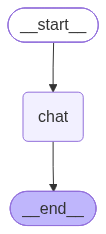

In [7]:
app

In [8]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}


# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "用非常简单的话解释一下梯度下降。")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)
    

In [9]:
result

{'messages': [HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ad1062a5-15f1-4401-9148-5d0f5c5b51a3')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': '用非常简单的话解释一下梯度下降。', 'instruction': 'Approve this question? yes/no'}, id='03d87754ea17141fa625673312d4a994')]}

In [10]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': '用非常简单的话解释一下梯度下降。',
 'instruction': 'Approve this question? yes/no'}

In [11]:
# Cursor/VS Code 的 Notebook 里 input() 经常弹不出输入框，会一直卡住。
# 演示 HITL 时直接赋值即可；要拒绝就改成 "no"。
print("Backend message:", message)
user_input = "yes"  # 改成 "no" 可走拒绝分支
print("人工审批结果:", user_input)

Backend message: {'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': '用非常简单的话解释一下梯度下降。', 'instruction': 'Approve this question? yes/no'}
人工审批结果: yes


# resume — 批准或拒绝

用 `Command(resume=...)` 继续同一 `thread_id`。


In [12]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [13]:
print(final_result["messages"][-1].content)

想象你站在一座大山上，**蒙着眼睛**，想要走到山脚下最低的地方。

梯度下降就是你用的那个笨办法：

1.  **伸脚试试**：用脚感受一下，哪个方向是往下走的（这就是在找**梯度**，即最陡峭的下坡方向）。
2.  **往下迈一小步**：朝着最陡的那个方向走一小步。
3.  **重复**：站稳后，再伸脚试探新的最陡方向，再迈一小步。

就这样一步一步地挪，最后你就能走到山谷底部。

**对应到机器学习里：**

-   **大山** = 错误率（你想让它降到最低的东西）
-   **你站的位置** = 模型当前的参数
-   **伸脚试探** = 计算梯度（求导）
-   **往下迈步** = 更新参数

目标就是找到让错误最小的那组参数。


In [14]:
final_result["messages"]

[HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ad1062a5-15f1-4401-9148-5d0f5c5b51a3'),
 AIMessage(content='想象你站在一座大山上，**蒙着眼睛**，想要走到山脚下最低的地方。\n\n梯度下降就是你用的那个笨办法：\n\n1.  **伸脚试试**：用脚感受一下，哪个方向是往下走的（这就是在找**梯度**，即最陡峭的下坡方向）。\n2.  **往下迈一小步**：朝着最陡的那个方向走一小步。\n3.  **重复**：站稳后，再伸脚试探新的最陡方向，再迈一小步。\n\n就这样一步一步地挪，最后你就能走到山谷底部。\n\n**对应到机器学习里：**\n\n-   **大山** = 错误率（你想让它降到最低的东西）\n-   **你站的位置** = 模型当前的参数\n-   **伸脚试探** = 计算梯度（求导）\n-   **往下迈步** = 更新参数\n\n目标就是找到让错误最小的那组参数。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 190, 'prompt_tokens': 12, 'total_tokens': 202, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-pro', 'system_fingerprint': 'fp_9954b31ca7_prod0820_fp8_kvcache_20260402', 'id': '7e3588fa-db76-4eca-ae2d-5aa2e0fa

In [29]:
# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "讲大灰狼的故事。")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)
    

In [30]:
final_result = app.invoke(
    Command(resume={"approved": "no"}),
    config=config,
)

In [28]:
final_result["messages"]

[HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ad1062a5-15f1-4401-9148-5d0f5c5b51a3'),
 AIMessage(content='想象你站在一座大山上，**蒙着眼睛**，想要走到山脚下最低的地方。\n\n梯度下降就是你用的那个笨办法：\n\n1.  **伸脚试试**：用脚感受一下，哪个方向是往下走的（这就是在找**梯度**，即最陡峭的下坡方向）。\n2.  **往下迈一小步**：朝着最陡的那个方向走一小步。\n3.  **重复**：站稳后，再伸脚试探新的最陡方向，再迈一小步。\n\n就这样一步一步地挪，最后你就能走到山谷底部。\n\n**对应到机器学习里：**\n\n-   **大山** = 错误率（你想让它降到最低的东西）\n-   **你站的位置** = 模型当前的参数\n-   **伸脚试探** = 计算梯度（求导）\n-   **往下迈步** = 更新参数\n\n目标就是找到让错误最小的那组参数。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 190, 'prompt_tokens': 12, 'total_tokens': 202, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-pro', 'system_fingerprint': 'fp_9954b31ca7_prod0820_fp8_kvcache_20260402', 'id': '7e3588fa-db76-4eca-ae2d-5aa2e0fa

In [31]:
app.get_state_history(config)

<generator object Pregel.get_state_history at 0x000002CA054E4040>

In [32]:
app.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ad1062a5-15f1-4401-9148-5d0f5c5b51a3'), AIMessage(content='想象你站在一座大山上，**蒙着眼睛**，想要走到山脚下最低的地方。\n\n梯度下降就是你用的那个笨办法：\n\n1.  **伸脚试试**：用脚感受一下，哪个方向是往下走的（这就是在找**梯度**，即最陡峭的下坡方向）。\n2.  **往下迈一小步**：朝着最陡的那个方向走一小步。\n3.  **重复**：站稳后，再伸脚试探新的最陡方向，再迈一小步。\n\n就这样一步一步地挪，最后你就能走到山谷底部。\n\n**对应到机器学习里：**\n\n-   **大山** = 错误率（你想让它降到最低的东西）\n-   **你站的位置** = 模型当前的参数\n-   **伸脚试探** = 计算梯度（求导）\n-   **往下迈步** = 更新参数\n\n目标就是找到让错误最小的那组参数。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 190, 'prompt_tokens': 12, 'total_tokens': 202, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-pro', 'system_fingerprint': 'fp_9954b31ca7_prod0820_fp8_kvcache_20260402', 'id': 